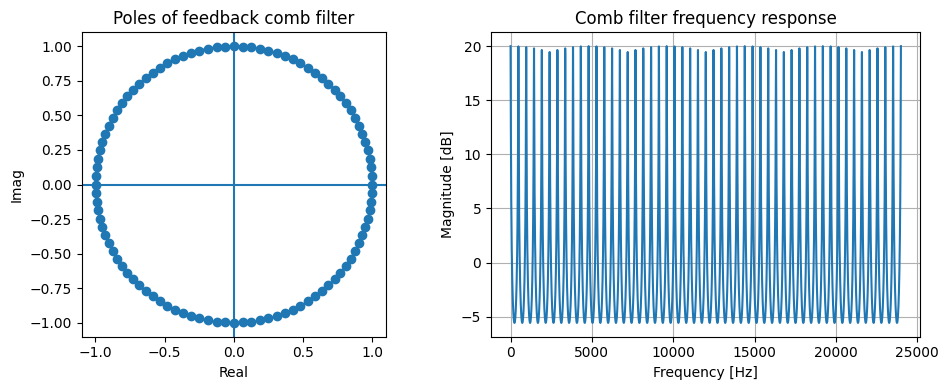

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def comb_poles(g, M):
    """Return the poles of a feedback comb filter H(z) = 1 / (1 - g z^{-M})."""
    radius = np.abs(g) ** (1.0 / M)
    ks = np.arange(M)
    angles = 2 * np.pi * ks / M
    poles = radius * np.exp(1j * angles)
    return poles

def plot_comb_example():
    Fs = 48000        # sample rate
    g = 0.9           # feedback gain
    M = 100           # delay length in samples

    poles = comb_poles(g, M)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # --- (1) Pole plot ---
    ax = axs[0]
    # unit circle
    theta = np.linspace(0, 2*np.pi, 512)
    unit_circle = np.exp(1j * theta)
    ax.plot(unit_circle.real, unit_circle.imag)
    ax.scatter(poles.real, poles.imag)
    ax.axhline(0)
    ax.axvline(0)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imag')
    ax.set_title('Poles of feedback comb filter')

    # --- (2) Frequency response ---
    ax = axs[1]
    w = np.linspace(0, np.pi, 4096)          # rad/sample
    z = np.exp(1j * w)
    H = 1.0 / (1.0 - g * z ** (-M))
    mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-8))
    freqs = w / np.pi * (Fs / 2.0)

    ax.plot(freqs, mag_db)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Magnitude [dB]')
    ax.set_title('Comb filter frequency response')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_comb_example()

/var/folders/ch/6ptk_lpn2kbg9l0vj3cd2lj40000gn/T/ipykernel_27273/465001331.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H[i] = c.conj().T @ np.linalg.inv(I - A @ D) @ b


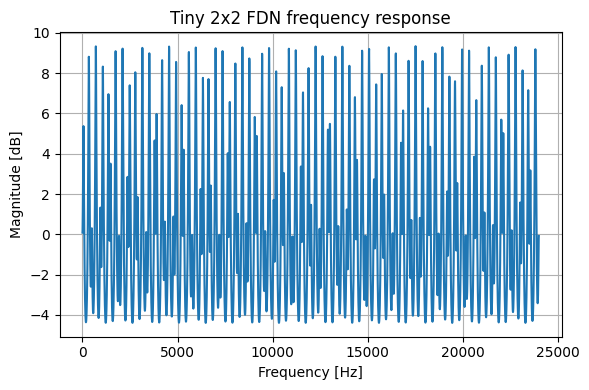

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def fdn_freq_response(A, m, b, c, Fs=48000, n_points=4096):
    """
    Compute frequency response H(e^{jw}) of an N-line FDN:
        H(z) = c^T (I - A D(z))^{-1} b,
    where D(z) = diag(z^{-m_i}).
    """
    m = np.array(m, dtype=int)
    N = len(m)
    w = np.linspace(0, np.pi, n_points)
    H = np.zeros_like(w, dtype=complex)
    I = np.eye(N, dtype=complex)

    for i, wi in enumerate(w):
        zinv = np.exp(-1j * wi)
        D = np.diag(zinv ** m)
        H[i] = c.conj().T @ np.linalg.inv(I - A @ D) @ b

    freqs = w / np.pi * (Fs / 2.0)
    return freqs, H

def plot_fdn_2x2_example():
    Fs = 48000
    # Delay lengths
    m = [100, 137]

    # Feedback matrix: scaled 2x2 Hadamard (orthogonal)
    U = (1 / np.sqrt(2)) * np.array([[1,  1],
                                     [-1, 1]], dtype=float)
    g = 0.7  # global feedback gain
    A = g * U

    N = len(m)
    # Simple input/output gains: equal into/out of all lines
    b = np.ones((N, 1)) / np.sqrt(N)
    c = np.ones((N, 1)) / np.sqrt(N)

    freqs, H = fdn_freq_response(A, m, b, c, Fs)
    mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-8))

    plt.figure(figsize=(6, 4))
    plt.plot(freqs, mag_db)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.title('Tiny 2x2 FDN frequency response')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_fdn_2x2_example()


/var/folders/ch/6ptk_lpn2kbg9l0vj3cd2lj40000gn/T/ipykernel_27273/465001331.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H[i] = c.conj().T @ np.linalg.inv(I - A @ D) @ b


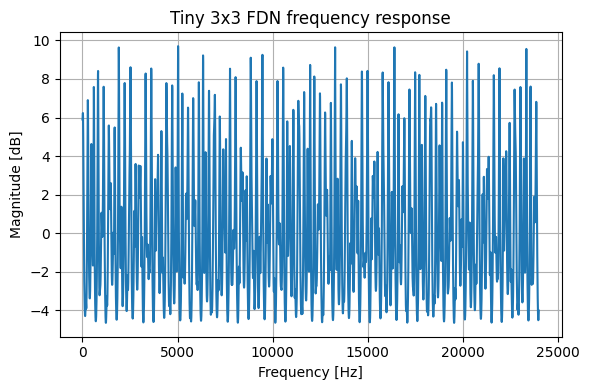

In [4]:

Fs = 48000
m = [97, 131, 173]  # three prime-ish delays

# A simple 3x3 orthogonal-ish matrix (scaled)
U = (1 / np.sqrt(3)) * np.array([[ 1,  1,  1],
                                    [ 1, -1,  1],
                                    [-1,  1,  1]], dtype=float)
g = 0.7
A = g * U

N = len(m)
b = np.ones((N, 1)) / np.sqrt(N)
c = np.ones((N, 1)) / np.sqrt(N)

freqs, H = fdn_freq_response(A, m, b, c, Fs)
mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-8))

plt.figure(figsize=(6, 4))
plt.plot(freqs, mag_db)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Tiny 3x3 FDN frequency response')
plt.grid(True)
plt.tight_layout()
plt.show()


Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/theoretical_plots/fig1_feedback_comb_mag.png
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/theoretical_plots/fig1_feedback_comb_mag.pdf
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/paper_assets/figures/fig1_feedback_comb_mag.png
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/paper_assets/figures/fig1_feedback_comb_mag.pdf


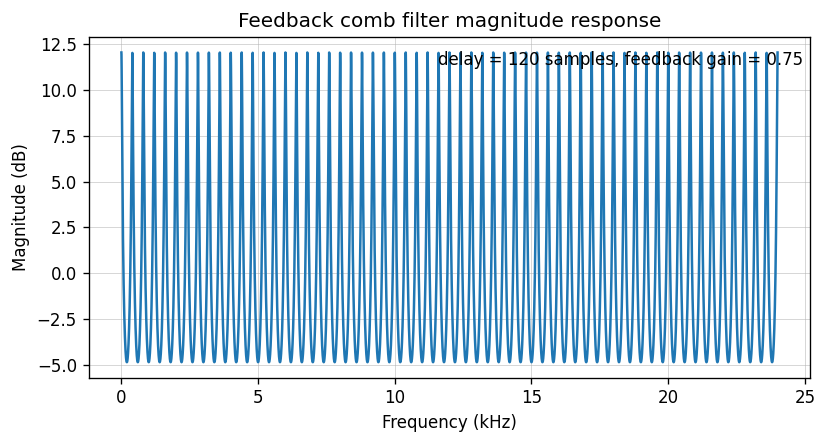

Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/theoretical_plots/fig2_allpass_impulse_comparison.png
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/theoretical_plots/fig2_allpass_impulse_comparison.pdf
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/paper_assets/figures/fig2_allpass_impulse_comparison.png
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/paper_assets/figures/fig2_allpass_impulse_comparison.pdf


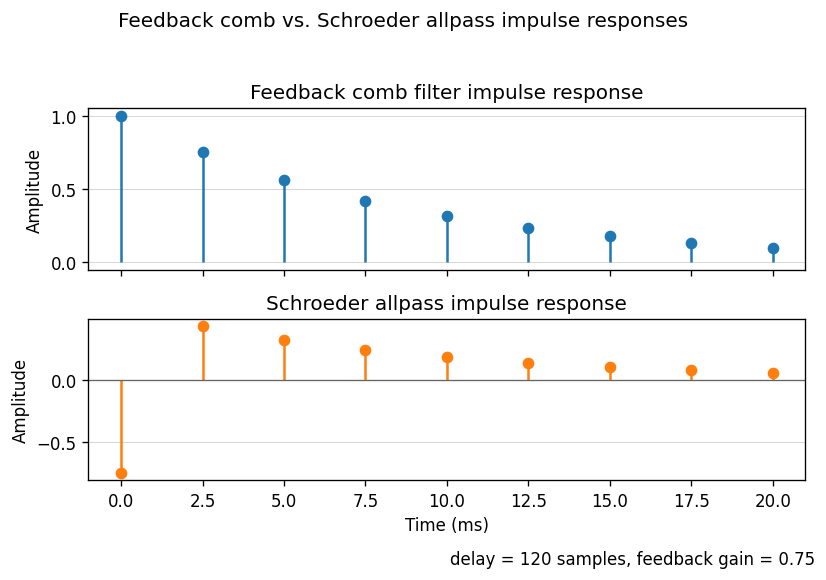

Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/theoretical_plots/waveform_to_delayed_samples.png
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/theoretical_plots/waveform_to_delayed_samples.pdf
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/paper_assets/figures/waveform_to_delayed_samples.png
Wrote /Users/user/Documents/GitHub/tiny-fdn-reverb/paper_assets/figures/waveform_to_delayed_samples.pdf


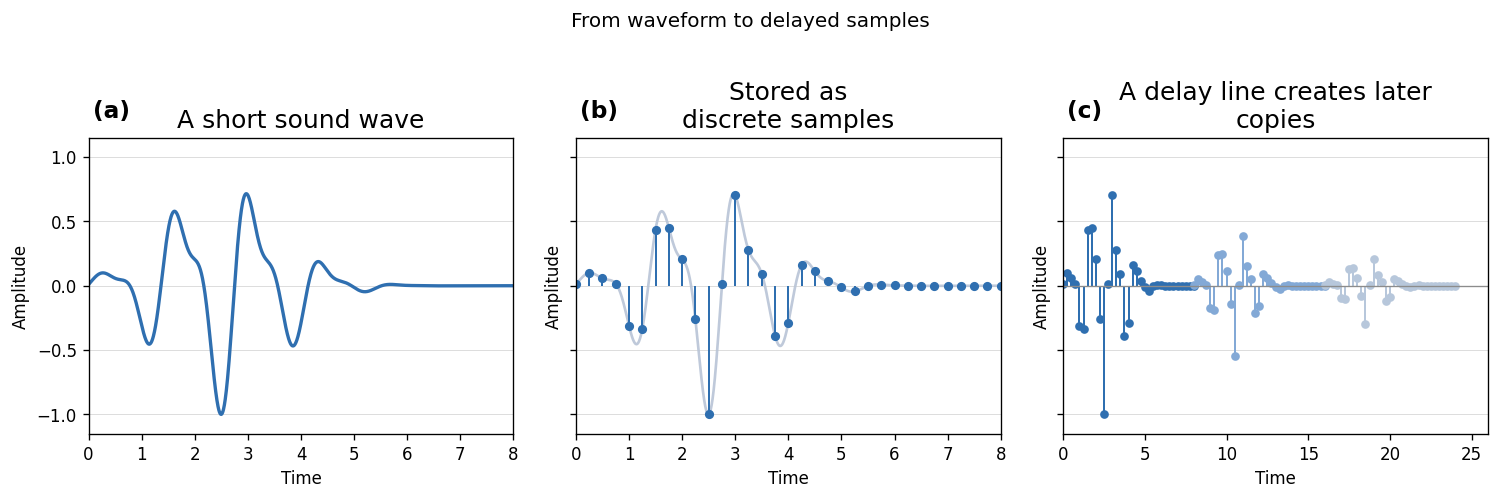

In [6]:
from pathlib import Path

fs = 48_000
m = 120
g = 0.75
n_fft = 16_384
n_impulses = 8

repo_root = Path.cwd()
if (repo_root / "theoretical_plots").is_dir():
    plot_dir = repo_root / "theoretical_plots"
elif repo_root.name == "theoretical_plots":
    plot_dir = repo_root
    repo_root = repo_root.parent
else:
    plot_dir = repo_root

paper_fig_dir = repo_root / "paper_assets" / "figures"
paper_fig_dir.mkdir(parents=True, exist_ok=True)
output_dirs = [plot_dir, paper_fig_dir]

def mag_db(H, floor_db=-120.0):
    mag = np.maximum(np.abs(H), 10 ** (floor_db / 20.0))
    return 20.0 * np.log10(mag)

def save_publication_figure(fig, stem):
    for output_dir in output_dirs:
        png_path = output_dir / f"{stem}.png"
        pdf_path = output_dir / f"{stem}.pdf"
        fig.savefig(png_path, dpi=160, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Wrote {png_path}")
        print(f"Wrote {pdf_path}")

w = np.linspace(0.0, np.pi, n_fft // 2 + 1)
f_khz = (w / (2.0 * np.pi)) * fs / 1000.0

# Figure 1: feedback comb filter magnitude response.
H_comb = 1.0 / (1.0 - g * np.exp(-1j * w * m))

fig, ax = plt.subplots(figsize=(7.0, 3.8), dpi=120)
ax.plot(f_khz, mag_db(H_comb), linewidth=1.5)
ax.set_xlabel("Frequency (kHz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Feedback comb filter magnitude response")
ax.text(
    0.99,
    0.96,
    f"delay = {m} samples, feedback gain = {g}",
    transform=ax.transAxes,
    ha="right",
    va="top",
)
ax.grid(True, which="both", linewidth=0.5, alpha=0.6)
fig.tight_layout()
save_publication_figure(fig, "fig1_feedback_comb_mag")
plt.show()

# Figure 2: time-domain comparison for the paper.
# The Schroeder allpass has unit magnitude for all frequencies, so an
# impulse-response plot is more instructive here than a flat magnitude plot.
impulse_index = np.arange(n_impulses + 1)
time_ms = impulse_index * m / fs * 1000.0
comb_impulse = g ** impulse_index
allpass_impulse = np.empty_like(comb_impulse)
allpass_impulse[0] = -g
allpass_impulse[1:] = (1.0 - g ** 2) * (g ** (impulse_index[1:] - 1))

fig, axs = plt.subplots(2, 1, figsize=(7.0, 4.8), sharex=True, dpi=120)

comb_markerline, comb_stemlines, _ = axs[0].stem(time_ms, comb_impulse, basefmt=" ")
plt.setp(comb_markerline, markersize=6)
plt.setp(comb_stemlines, linewidth=1.5)
axs[0].set_ylabel("Amplitude")
axs[0].set_title("Feedback comb filter impulse response")
axs[0].grid(True, axis="y", linewidth=0.5, alpha=0.6)

allpass_markerline, allpass_stemlines, _ = axs[1].stem(
    time_ms,
    allpass_impulse,
    linefmt="C1-",
    markerfmt="C1o",
    basefmt=" ",
)
plt.setp(allpass_markerline, markersize=6)
plt.setp(allpass_stemlines, linewidth=1.5)
axs[1].axhline(0.0, color="0.4", linewidth=0.8)
axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("Amplitude")
axs[1].set_title("Schroeder allpass impulse response")
axs[1].grid(True, axis="y", linewidth=0.5, alpha=0.6)

fig.suptitle("Feedback comb vs. Schroeder allpass impulse responses", y=0.98)
fig.text(0.99, 0.02, f"delay = {m} samples, feedback gain = {g}", ha="right")
fig.tight_layout(rect=(0.0, 0.04, 1.0, 0.95))
save_publication_figure(fig, "fig2_allpass_impulse_comparison")
plt.show()

# Figure 3: pedagogical signal-to-samples-to-delay-line story for Section 2.1.
t_dense = np.linspace(0.0, 0.008, 2000)
envelope = np.exp(-0.5 * ((t_dense - 0.0025) / 0.0011) ** 2)
carrier = (
    0.9 * np.sin(2.0 * np.pi * 720.0 * t_dense)
    + 0.35 * np.sin(2.0 * np.pi * 1450.0 * t_dense + 0.45)
)
burst_dense = envelope * carrier
burst_dense /= np.max(np.abs(burst_dense))

sample_interval = 0.00025
t_samples = np.arange(0.0, 0.008 + sample_interval / 2.0, sample_interval)
burst_samples = np.interp(t_samples, t_dense, burst_dense)
time_dense_ms = t_dense * 1000.0
time_samples_ms = t_samples * 1000.0

delay_1_ms = 8.0
delay_2_ms = 16.0
delay_scale_1 = 0.55
delay_scale_2 = 0.30

fig, axs = plt.subplots(1, 3, figsize=(12.6, 4.0), dpi=120, sharey=True)
original_color = "#2f6fb0"
delay_color_1 = "#83a9d6"
delay_color_2 = "#b7c7db"
background_color = "#b8c4d6"

axs[0].plot(time_dense_ms, burst_dense, color=original_color, linewidth=2.0)
axs[0].set_title("A short sound wave", fontsize=15)
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].set_xlim(0.0, 8.0)
axs[0].set_ylim(-1.15, 1.15)
axs[0].grid(True, axis="y", linewidth=0.5, alpha=0.5)

axs[1].plot(time_dense_ms, burst_dense, color=background_color, linewidth=1.6, alpha=0.9)
sample_markerline, sample_stemlines, _ = axs[1].stem(
    time_samples_ms,
    burst_samples,
    linefmt=original_color,
    markerfmt="o",
    basefmt=" ",
)
plt.setp(sample_markerline, markersize=4.5, markerfacecolor=original_color, markeredgecolor=original_color)
plt.setp(sample_stemlines, linewidth=1.2, color=original_color)
axs[1].set_title("Stored as\ndiscrete samples", fontsize=15)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Amplitude")
axs[1].set_xlim(0.0, 8.0)
axs[1].grid(True, axis="y", linewidth=0.5, alpha=0.5)

orig_markerline, orig_stemlines, _ = axs[2].stem(
    time_samples_ms,
    burst_samples,
    linefmt=original_color,
    markerfmt="o",
    basefmt=" ",
)
delay1_markerline, delay1_stemlines, _ = axs[2].stem(
    time_samples_ms + delay_1_ms,
    delay_scale_1 * burst_samples,
    linefmt=delay_color_1,
    markerfmt="o",
    basefmt=" ",
)
delay2_markerline, delay2_stemlines, _ = axs[2].stem(
    time_samples_ms + delay_2_ms,
    delay_scale_2 * burst_samples,
    linefmt=delay_color_2,
    markerfmt="o",
    basefmt=" ",
)
for markerline, stemlines, color in [
    (orig_markerline, orig_stemlines, original_color),
    (delay1_markerline, delay1_stemlines, delay_color_1),
    (delay2_markerline, delay2_stemlines, delay_color_2),
]:
    plt.setp(markerline, markersize=4.2, markerfacecolor=color, markeredgecolor=color)
    plt.setp(stemlines, linewidth=1.2, color=color)
axs[2].axhline(0.0, color="0.55", linewidth=0.8)
axs[2].set_title("A delay line creates later\ncopies", fontsize=15)
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Amplitude")
axs[2].set_xlim(0.0, 26.0)
axs[2].grid(True, axis="y", linewidth=0.5, alpha=0.5)

for label, ax in zip(["(a)", "(b)", "(c)"], axs):
    ax.text(0.01, 1.05, label, transform=ax.transAxes, ha="left", va="bottom", fontweight="bold", fontsize=14)

fig.suptitle("From waveform to delayed samples", y=1.03)
fig.tight_layout(w_pad=1.6)
save_publication_figure(fig, "waveform_to_delayed_samples")
plt.show()
